<div style="
    background-color: #fff3cd; 
    border-left: 4px solid #f0ad4e; 
    padding: 10px 12px; 
    border-radius: 6px;
    color: #664d03;
">
测试环境使用cst，Jupyter环境名是cellscape_test
</div>

# 空转测试数据生成

## 真实数据

In [ ]:
%reset -f
import scanpy as sc
import squidpy as sq

# 背景图数据
adata = sc.datasets.visium_sge(sample_id="V1_Human_Lymph_Node")
adata.var_names_make_unique()

adata

In [ ]:
import squidpy as sq
import cellscape.styles as sty

sq.pl.spatial_scatter(adata, 
                      color='MS4A1',
                      cmap=sty.seurat_heat(),
                      frameon=False,
                      img=True, 
                      )

## 随机数据

### 随机表达数据生成

In [ ]:
%reset -f
# 多library数据
import numpy as np
import pandas as pd
import anndata as ad
from anndata import AnnData

rng = np.random.default_rng(2026)

n_libs = 3
n_spots_per_lib = 200
n_genes = 100
celltypes = np.array(["Neuron", "Astro", "Microglia", "Oligo"])
celltype_centers = {
    "Neuron": (300, 300),
    "Astro": (700, 300),
    "Microglia": (300, 700),
    "Oligo": (700, 700),
}

adatas = []

for i in range(n_libs):
    library_id = f"lib{i}"

    X = rng.poisson(
        lam=2,
        size=(n_spots_per_lib, n_genes)
    )

    celltype = rng.choice(celltypes, n_spots_per_lib)
    centers = np.array([celltype_centers[ct] for ct in celltype])
    xy = np.clip(
        rng.normal(loc=centers, scale=220, size=(n_spots_per_lib, 2)),
        0,
        1000,
    )

    obs = pd.DataFrame({
        "library": library_id,
        "x": xy[:, 0],
        "y": xy[:, 1],
        "celltype": celltype,
    })

    obs.index = [f"{library_id}_spot{i}" for i in range(n_spots_per_lib)]

    var = pd.DataFrame(
        index=[f"Gene{j}" for j in range(n_genes)]
    )

    adata_i = AnnData(X=X, obs=obs, var=var)
    adata_i.obsm["spatial"] = adata_i.obs[["x", "y"]].to_numpy()

    adatas.append(adata_i)

adata = ad.concat(adatas, index_unique=None)
# sq.pl.spatial_scatter绘图需要这个键有值
adata.uns['spatial'] = {'lib0':{}, 'lib1':{}, 'lib2':{}}

### 随机背景图片生成

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager as fm

def make_bg(lib, out_dir="library_backgrounds", size=1000, tri=80):
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)

    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)

    # 四个角的三角形
    draw.polygon([(0, 0), (tri, 0), (0, tri)], fill="black")                         # 左上
    draw.polygon([(size, 0), (size - tri, 0), (size, tri)], fill="black")             # 右上
    draw.polygon([(0, size), (tri, size), (0, size - tri)], fill="black")             # 左下
    draw.polygon([(size, size), (size - tri, size), (size, size - tri)], fill="black") # 右下

    # 中间写 library 编号
    # 自动找一个 matplotlib 自带字体
    font_path = fm.findfont("DejaVu Sans")
    font = ImageFont.truetype(font_path, size=80)
    text = str(lib)
    box = draw.textbbox((0, 0), text, font=font)
    x = (size - (box[2] - box[0])) / 2
    y = (size - (box[3] - box[1])) / 2
    draw.text((x, y), text, fill="black", font=font)

    img.save(out_dir / f"{lib}.png")

library_ids = ["lib0", "lib1", "lib2"]

for lib in library_ids:
    make_bg(lib)

In [ ]:
import numpy as np
from PIL import Image

for lib in library_ids:
    img_path = f"library_backgrounds/{lib}.png"
    img = np.array(Image.open(img_path))

    if "spatial" not in adata.uns:
        adata.uns["spatial"] = {}

    if lib not in adata.uns["spatial"]:
        adata.uns["spatial"][lib] = {}

    adata.uns["spatial"][lib]["images"] = {
        "hires": img,
        "lowres": img,
    }

    adata.uns["spatial"][lib]["scalefactors"] = {
        "tissue_hires_scalef": 1.0,
        "tissue_lowres_scalef": 1.0,
        "spot_diameter_fullres": 1.0,
    }

    adata.uns["spatial"][lib]["metadata"] = {
        "source_image_path": img_path
    }

In [ ]:
import squidpy as sq
import cellscape.styles as sty

sq.pl.spatial_scatter(adata, 
                      color='celltype',
                      library_key="library", 
                      library_id=['lib0', 'lib1', 'lib2'],
                      cmap=sty.seurat_heat(),
                      frameon=False,
                      img=True, 
                      size=20,
                      )

In [ ]:
import scanpy as sc

# 保留原始counts
adata.layers["counts"] = adata.X.copy()

# 标准预处理
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers["lognorm"] = adata.X.copy()

# PCA / 邻接图 / UMAP
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=10)
sc.tl.umap(adata)

adata.write_h5ad("example_sp_data.h5ad")
adata

# `plot.py`绘图函数测试

## 测试`spatial_expression_panels`

In [ ]:
%reset -f
import scanpy as sc
import matplotlib.pyplot as plt
import cellscape.spatial as spt

adata = sc.read_h5ad("example_sp_data.h5ad")

fig, axes = spt.spatial_expression_panels(
    adata=adata,
    gene="celltype",
    panels=['lib1','lib0'],
    library_key='library',
    spatial_key='spatial',
    layer='lognorm',
    size=20,
    img=True,
    show=True,
)

## 测试`highlight_clusters_panels`

In [ ]:
%reset -f
import scanpy as sc
import matplotlib.pyplot as plt
import cellscape.spatial as spt

adata = sc.read_h5ad("example_sp_data.h5ad")

fig, axes = spt.highlight_clusters_panels(
    adata=adata,
    color_key="celltype",
    select_cluster=None,
    panels=['lib0','lib1','lib2'],
    library_key='library',
    spatial_key='spatial',
    layer='lognorm',
    size=20,
    img=True,
    show=True,
)

## 测试`highlight_and_expression_grid`

In [ ]:
%reset -f
import scanpy as sc
import matplotlib.pyplot as plt
import cellscape.spatial as spt

adata = sc.read_h5ad("example_sp_data.h5ad")
fig, axes = spt.highlight_and_expression_grid(
    adata=adata,
    row_panels=["Gene10", "Gene14", ],
    column_panels=['lib0','lib1','lib2'],
    group_key='celltype',
    show=True,
)

In [ ]:
%reset -f
import scanpy as sc
import matplotlib.pyplot as plt
import cellscape.spatial as spt

adata = sc.read_h5ad("example_sp_data.h5ad")
fig, axes = spt.highlight_and_expression_grid(
    adata=adata,
    row_panels=["Gene10", "Gene14"],
    column_panels=['lib0','lib1','lib2'],
    group_key='celltype',
    select_cluster="Oligo",
    crop_to_selected=True,
    crop_extend_factor=1,
    img_group=True,
    show=True,
)

# `annotation.py`注释函数测试

## 测试`project_labelme_masks_to_obs`

In [1]:
# 测试读取模式npy和写入模式separate
%reset -f
import scanpy as sc
import cellscape.spatial as spt

adata = sc.read_h5ad("example_sp_data.h5ad")
adata = spt.project_labelme_masks_to_obs(
    adata=adata,
    mask_path_dict={'lib0':"library_backgrounds/masks/SegmentationClassNpy/lib0.npy",
                    'lib1':"library_backgrounds/masks/SegmentationClassNpy/lib1.npy",
                    'lib2':"library_backgrounds/masks/SegmentationClassNpy/lib2.npy"},
    labels=["__ignore__", "_background_", "test"],
    inplace=False,
)
adata.obs["region"] = "other"
adata.obs.loc[adata.obs["in_test"], "region"] = "test"
adata.obs.columns

投射 library mask:   0%|          | 0/3 [00:00<?, ?library/s]

写入 obs 区域列:   0%|          | 0/3 [00:00<?, ?region/s]

Index(['library', 'x', 'y', 'celltype', 'in___ignore__', 'in__background_',
       'in_test', 'region'],
      dtype='object')

In [ ]:
# 测试读取模式png和写入模式merge
%reset -f
import scanpy as sc
import cellscape.spatial as spt

adata = sc.read_h5ad("example_sp_data.h5ad")
adata = spt.project_labelme_masks_to_obs(
    adata=adata,
    mask_path_dict={'lib0':"library_backgrounds/masks/SegmentationClass/lib0",
                    'lib1':"library_backgrounds/masks/SegmentationClass/lib1",
                    'lib2':"library_backgrounds/masks/SegmentationClass/lib2"},
    mask_format='png',
    labels=["__ignore__", "_background_", "test"],
    write_mode="merge",
    region_key="region",
    inplace=False,
)

投射 library mask:   0%|          | 0/3 [00:00<?, ?library/s]

写入 obs 区域列:   0%|          | 0/3 [00:00<?, ?region/s]

/var/folders/dt/7dzhx38d0nj0_rtw34d7trx00000gn/T/ipykernel_2092/2562414088.py:3: UserWarning: adata.uns['region_colors'] is missing or has a length different from 'region' categories; generating 2 glasbey colors.
  fig, axes = spt.highlight_clusters_panels(


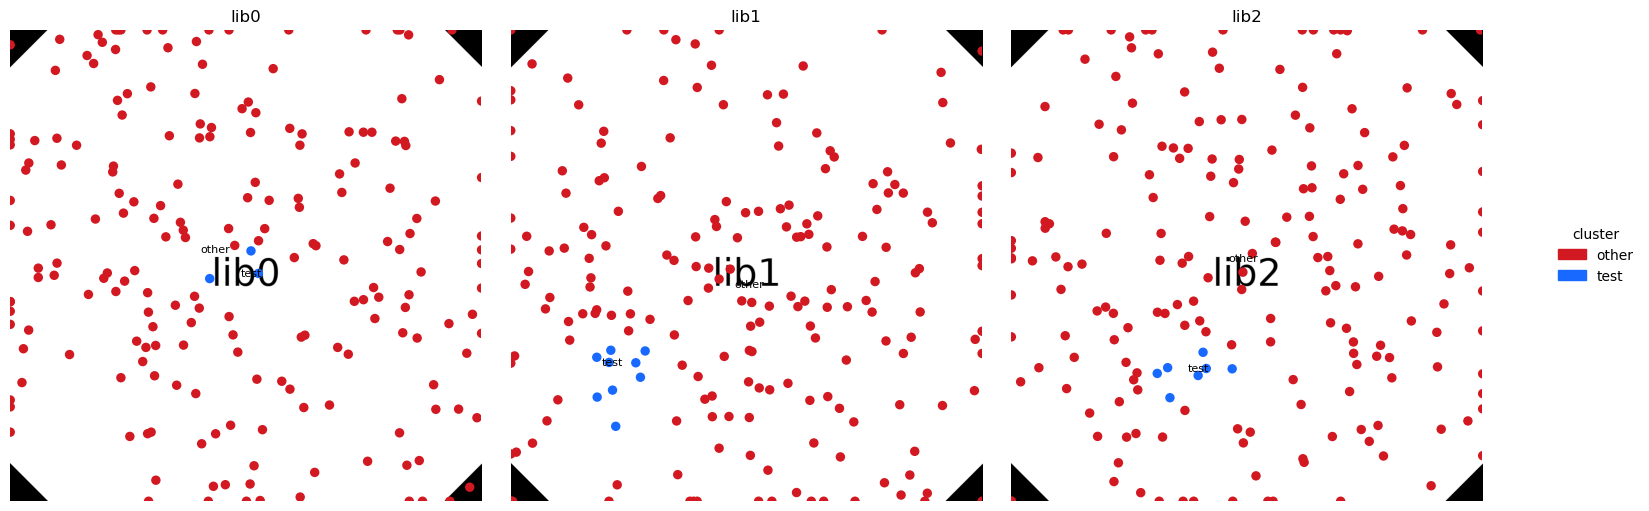

In [6]:
import matplotlib.pyplot as plt

fig, axes = spt.highlight_clusters_panels(
    adata=adata,
    color_key="region",
    select_cluster=None,
    panels=['lib0','lib1','lib2'],
    library_key='library',
    spatial_key='spatial',
    size=20,
    img=True,
    show=False,
)
plt.savefig("test_spatial.pdf", bbox_inches="tight", pad_inches=0.1)

# END